Publication-ready rolling out-of-sample tests

 Final model loaded: quantum_alpha_final.pth

=== WALK-FORWARD VALIDATION RESULTS ===
            Train Window            Test Window  CAGR (%)  Sharpe  MaxDD (%)  \
0  2019-01-01–2020-12-31  2021-01-01–2021-12-31     10.95  0.4495      -5.69   
1  2019-01-01–2021-12-31  2022-01-01–2022-12-31     30.01  1.8186      -3.66   
2  2020-01-01–2022-12-31  2023-01-01–2023-12-31     -3.71 -1.9571      -6.14   
3  2021-01-01–2023-12-31  2024-01-01–2024-12-31     -7.64 -2.1061     -10.69   
4  2022-01-01–2024-12-31  2025-01-01–2025-12-31      1.19 -0.8116      -7.88   

   Flat %  Days  
0    75.7   248  
1    67.2   248  
2    75.8   245  
3    68.2   246  
4    58.7   248  

=== OUT-OF-SAMPLE ROBUSTNESS SUMMARY ===
Average Sharpe     : -0.5213
Sharpe Std Dev     : 1.6640
Average MaxDD      : -6.81%
Average Flat %     : 69.1%


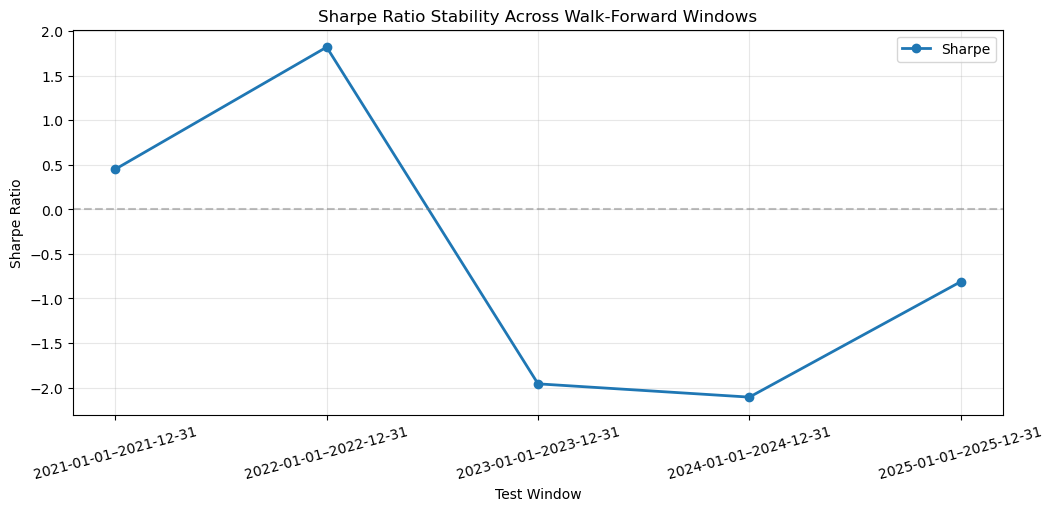

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Publication-ready rolling out-of-sample tests\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. WALK-FORWARD WINDOWS (Rolling 2-year train → 1-year test)
# =============================================
full_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
full_data = full_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])

# Rolling windows
windows = [
    ("2019-01-01", "2020-12-31", "2021-01-01", "2021-12-31"),
    ("2019-01-01", "2021-12-31", "2022-01-01", "2022-12-31"),
    ("2020-01-01", "2022-12-31", "2023-01-01", "2023-12-31"),
    ("2021-01-01", "2023-12-31", "2024-01-01", "2024-12-31"),
    ("2022-01-01", "2024-12-31", "2025-01-01", "2025-12-31")
]

wf_results = []

for train_start, train_end, test_start, test_end in windows:
    # Test window only (walk-forward uses previous train data implicitly through the trained model)
    test_data = full_data.loc[test_start:test_end].copy()
    
    env = QuantumAlphaEnv(test_data)
    state = env.reset()
    done = False
    equity = 1.0
    equity_curve = [1.0]
    returns = []
    positions = []
    
    while not done:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = policy_net(s).argmax().item()
        next_state, _, done, info = env.step(action)
        equity *= (1 + info["net_ret"])
        equity_curve.append(equity)
        returns.append(info["net_ret"])
        positions.append(info["position"])
        state = next_state
    
    equity_arr = np.array(equity_curve)
    returns = np.array(returns)
    pos = np.array(positions)
    
    days = len(returns)
    cagr = equity_arr[-1] ** (252 / days) - 1 if days > 0 else 0
    sharpe = (np.mean(returns) - 0.065/252) / (np.std(returns) + 1e-8) * np.sqrt(252) if days > 0 else 0
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    
    wf_results.append({
        "Train Window": f"{train_start}–{train_end}",
        "Test Window": f"{test_start}–{test_end}",
        "CAGR (%)": round(cagr*100, 2),
        "Sharpe": round(sharpe, 4),
        "MaxDD (%)": round(max_dd*100, 2),
        "Flat %": round((pos == 0).mean()*100, 1),
        "Days": len(test_data)
    })

wf_df = pd.DataFrame(wf_results)
print("\n=== WALK-FORWARD VALIDATION RESULTS ===")
print(wf_df)

# Summary statistics
print("\n=== OUT-OF-SAMPLE ROBUSTNESS SUMMARY ===")
print(f"Average Sharpe     : {wf_df['Sharpe'].mean():.4f}")
print(f"Sharpe Std Dev     : {wf_df['Sharpe'].std():.4f}")
print(f"Average MaxDD      : {wf_df['MaxDD (%)'].mean():.2f}%")
print(f"Average Flat %     : {wf_df['Flat %'].mean():.1f}%")

# =============================================
# 4. VISUALISATION — PERFORMANCE STABILITY
# =============================================
plt.figure(figsize=(12, 5))
plt.plot(wf_df["Test Window"], wf_df["Sharpe"], marker='o', linewidth=2, color="#1f77b4", label="Sharpe")
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Sharpe Ratio Stability Across Walk-Forward Windows")
plt.xlabel("Test Window")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()